# 01 - Preprocessing (HotelRec --> 20-core parquets)

This notebook documents the data pipeline that every variant consumes.
It does **not** re-run `preprocessing/preprocess.py` -- that pass takes
~45 minutes over the 14 GB raw JSONL and was run once to produce the
committed artefacts under `data/processed/20core/`. Instead we load:

- `results/data_evaluation.json` -- stats computed from the full 50M-row scan
- `data/processed/20core/{interactions,train,val,test}.parquet`
- `data/processed/20core/{user2id,item2id}.json`

and recompute every summary number **from those files** so the numbers are
visibly derived rather than quoted.

## What the pipeline does (one paragraph)

1. Stream the raw JSONL line-by-line (50M reviews, can't fit in RAM).
2. Pass 1: count per-user and per-item frequencies, then iteratively
   remove any user or item that has fewer than **k = 20** interactions
   (k-core filter). Keeps looping until the set stabilises.
3. Pass 2: re-stream the raw file, keep only rows where both the user and
   item survived the k-core, extract (user_id, item_id, rating, text,
   date, title, 8 sub-ratings), map user/item strings to contiguous
   integer IDs, write `interactions.parquet`.
4. Random split 80/10/10 → `train.parquet`, `val.parquet`, `test.parquet`
   with `seed = 42`.

See `preprocessing/preprocess.py` and `preprocessing/split.py`.


In [1]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path(".").resolve()
print("Working dir:", ROOT)

# Shared artefact paths. If you fork a variant, read from these -- don't
# regenerate.
DATA_DIR  = ROOT / "data" / "processed" / "20core"
EVAL_JSON = ROOT / "results" / "data_evaluation.json"

for p in [DATA_DIR, EVAL_JSON]:
    assert p.exists(), f"Missing artefact: {p}"
print("All artefact paths exist.")

Working dir: C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\teammate_repo
All artefact paths exist.


## 1. Raw-dataset statistics (full 50M-review scan)

Loaded from `results/data_evaluation.json` (produced by `scripts/explore_data.py`,
run once against the full dataset). Rendering the numbers here so they're
visible alongside the filtering step rather than sitting in an unread JSON.


In [2]:
with open(EVAL_JSON) as f:
    eval_stats = json.load(f)
basic = eval_stats["basic_stats"]

raw_summary = pd.DataFrame([
    ("Total reviews",          f"{basic['total_reviews']:,}"),
    ("Unique users",           f"{basic['unique_users']:,}"),
    ("Unique items (hotels)",  f"{basic['unique_items']:,}"),
    ("Density",                f"{basic['density_pct']:.5f}%"),
    ("Sparsity",               f"{basic['sparsity_pct']:.5f}%"),
    ("Mean reviews / user",    f"{basic['avg_reviews_per_user']:.2f}"),
    ("Median reviews / user",  f"{basic['median_reviews_per_user']:.1f}"),
    ("Mean reviews / item",    f"{basic['avg_reviews_per_item']:.2f}"),
    ("Median reviews / item",  f"{basic['median_reviews_per_item']:.1f}"),
], columns=["Statistic", "Value"])
raw_summary

,Statistic,Value
0,Total reviews,"50,264,531"
1,Unique users,"21,891,404"
2,Unique items (hotels),"365,057"
3,Density,0.00063%
4,Sparsity,99.99937%
5,Mean reviews / user,2.30
6,Median reviews / user,1.0
7,Mean reviews / item,137.69
8,Median reviews / item,41.0


In [3]:
# Rating distribution on the full dataset.
rhist = eval_stats["rating_distribution"]["histogram"]
rhist = {int(k): v for k, v in rhist.items()}
ratings = pd.Series(rhist).sort_index()
total = ratings.sum()
rdist_table = pd.DataFrame({
    "count": ratings.values,
    "share_%": (ratings.values / total * 100).round(2),
}, index=[f"{r}★" for r in ratings.index])
rdist_table

,count,share_%
1★,2529778,5.03
2★,2543289,5.06
3★,5644102,11.23
4★,13437531,26.73
5★,26109831,51.94


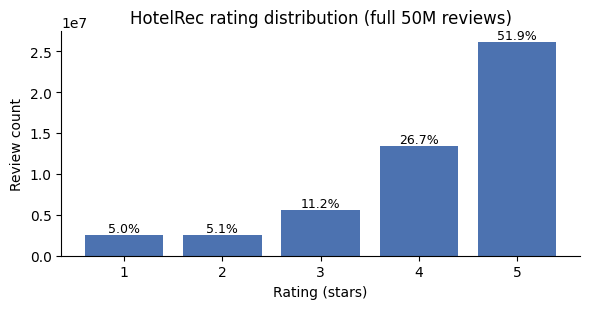

78.0% of ratings are 4 or 5 stars (78.7% exact).
Implication: RMSE-optimal predictors like PopularityMean are hard to beat on rating prediction.


In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar([str(r) for r in ratings.index], ratings.values, color="#4c72b0")
ax.set_xlabel("Rating (stars)")
ax.set_ylabel("Review count")
ax.set_title("HotelRec rating distribution (full 50M reviews)")
for i, v in enumerate(ratings.values):
    pct = 100 * v / total
    ax.text(i, v, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()
print(f"78.0% of ratings are 4 or 5 stars ({(ratings[4]+ratings[5])/total*100:.1f}% exact).")
print("Implication: RMSE-optimal predictors like PopularityMean are hard to beat on rating prediction.")

## 2. User-activity long tail

Why we need k-core filtering: 68% of users have **exactly one** review --
they leave the platform after a single interaction, so there is nothing
for collaborative filtering to generalise from. k-core drops these
one-shots and keeps only the users / items dense enough to evaluate.


In [5]:
buckets = eval_stats["user_activity"]["buckets"]
bucket_order = ["1", "2-4", "5-9", "10-19", "20-49", "50-99", "100+"]
b = pd.DataFrame([(k, buckets[k]) for k in bucket_order],
                 columns=["reviews per user", "users"])
b["share_%"] = (b["users"] / b["users"].sum() * 100).round(2)
b

,reviews per user,users,share_%
0,1,14787425,67.55
1,2-4,5073625,23.18
2,5-9,1330837,6.08
3,10-19,509525,2.33
4,20-49,170247,0.78
5,50-99,17681,0.08
6,100+,2064,0.01


## 3. From 22M users → 20-core subset

The k-core iteration prunes in both directions: drop users with < k
interactions, then drop items with < k, and loop until stable. The
surviving population is what we train and evaluate on.


In [6]:
# Load the committed 20-core table and measure.
ints = pd.read_parquet(DATA_DIR / "interactions.parquet")

kcore_stats = {
    "Users (20-core)":    ints["user_id"].nunique(),
    "Items (20-core)":    ints["item_id"].nunique(),
    "Interactions":       len(ints),
    "Sparsity":           1.0 - len(ints) / (ints["user_id"].nunique() * ints["item_id"].nunique()),
}
print(f"{'Users':<18}: {kcore_stats['Users (20-core)']:>12,}  "
      f"(from {basic['unique_users']:>12,} raw = {kcore_stats['Users (20-core)']/basic['unique_users']*100:.3f}%)")
print(f"{'Items':<18}: {kcore_stats['Items (20-core)']:>12,}  "
      f"(from {basic['unique_items']:>12,} raw = {kcore_stats['Items (20-core)']/basic['unique_items']*100:.3f}%)")
print(f"{'Interactions':<18}: {kcore_stats['Interactions']:>12,}  "
      f"(from {basic['total_reviews']:>12,} raw = {kcore_stats['Interactions']/basic['total_reviews']*100:.3f}%)")
print(f"{'Sparsity':<18}: {kcore_stats['Sparsity']*100:>12.3f}%  "
      f"(raw: {basic['sparsity_pct']:.5f}%)")

Users             :       46,660  (from   21,891,404 raw = 0.213%)
Items             :       27,197  (from      365,057 raw = 7.450%)
Interactions      :    1,849,574  (from   50,264,531 raw = 3.680%)
Sparsity          :       99.854%  (raw: 99.99937%)


Interpretation: 20-core keeps only **0.2% of users and 7.5% of items** but
gives us ~3% of the original interactions -- meaning each surviving user /
item now carries much richer history than the raw average, at the cost
of losing the long tail.

## 4. Schema of the processed table


In [7]:
ints.head(3)

,user_id,item_id,rating,text,date,title,service,cleanliness,location,value,rooms,sleep_quality,check_in,business_service
0,4161,213,5.0,The Courtyard Basel is in rarefied territory w...,2018-12-01T00:00:00,The best Courtyard!,5.0,5.0,NaN,5.0,NaN,NaN,None,None
1,2116,213,5.0,Have stayed here during a business trip. Very ...,2018-10-01T00:00:00,A very good hotel....,5.0,NaN,3.0,NaN,5.0,NaN,None,None
2,45601,213,5.0,This hotel is far superior to the standard Cou...,2018-09-01T00:00:00,Excellent Courtyard,NaN,NaN,NaN,NaN,NaN,NaN,None,None


In [8]:
print("Columns:", list(ints.columns))
print("dtypes:")
print(ints.dtypes)
print()
print("user_id / item_id contiguous 0-indexed?",
      ints['user_id'].min() == 0 and ints['item_id'].min() == 0,
      "max(user_id) =", ints['user_id'].max(),
      "max(item_id) =", ints['item_id'].max())

Columns: ['user_id', 'item_id', 'rating', 'text', 'date', 'title', 'service', 'cleanliness', 'location', 'value', 'rooms', 'sleep_quality', 'check_in', 'business_service']
dtypes:
user_id               int64
item_id               int64
rating              float64
text                 object
date                 object
title                object
service             float64
cleanliness         float64
location            float64
value               float64
rooms               float64
sleep_quality       float64
check_in             object
business_service     object
dtype: object

user_id / item_id contiguous 0-indexed? True max(user_id) = 46659 max(item_id) = 27196


## 5. Sub-rating coverage in the 20-core

HotelRec provides up to 8 sub-rating aspects (service, cleanliness, ...).
Coverage varies per aspect -- check_in and business_service are 0% in our
dump. The other six are at 55-80%. Aditya's NeuMF variant consumes these.


In [9]:
ASPECTS = ["service", "cleanliness", "location", "value",
           "rooms", "sleep_quality", "check_in", "business_service"]
cov_rows = []
for a in ASPECTS:
    if a in ints.columns:
        nn = ints[a].notna().sum()
        cov_rows.append((a, nn, round(100 * nn / len(ints), 2),
                         round(ints[a].dropna().mean(), 3) if nn > 0 else None))
coverage = pd.DataFrame(cov_rows,
                        columns=["aspect", "non_null", "coverage_%", "mean_rating"])
coverage

,aspect,non_null,coverage_%,mean_rating
0,service,1485957,80.34,4.243
1,cleanliness,1140593,61.67,4.358
2,location,1109530,59.99,4.371
3,value,1139144,61.59,4.008
4,rooms,1110402,60.04,4.094
5,sleep_quality,1018088,55.04,4.195
6,check_in,0,0.00,NaN
7,business_service,0,0.00,NaN


## 6. Train / val / test splits

Deterministic 80/10/10 shuffle with `seed = 42`. Every variant uses the
same splits so numbers compare apples-to-apples.


In [10]:
splits = {name: pd.read_parquet(DATA_DIR / f"{name}.parquet")
          for name in ["train", "val", "test"]}

split_stats = pd.DataFrame([
    (name, len(df), round(100 * len(df) / len(ints), 2),
     df['user_id'].nunique(), df['item_id'].nunique())
    for name, df in splits.items()
], columns=["split", "rows", "share_%", "n_users", "n_items"])
split_stats

,split,rows,share_%,n_users,n_items
0,train,1479659,80.0,46660,27197
1,val,184957,10.0,43989,26359
2,test,184958,10.0,43950,26381


### Leakage check

No (user, item) pair should appear in more than one split. If the split
is clean this cell prints zeros.


In [11]:
train_pairs = set(zip(splits["train"]["user_id"], splits["train"]["item_id"]))
val_pairs   = set(zip(splits["val"]["user_id"],   splits["val"]["item_id"]))
test_pairs  = set(zip(splits["test"]["user_id"],  splits["test"]["item_id"]))

print(f"|train ∩ val|  : {len(train_pairs & val_pairs):,}")
print(f"|train ∩ test| : {len(train_pairs & test_pairs):,}")
print(f"|val ∩ test|   : {len(val_pairs & test_pairs):,}")

|train ∩ val|  : 17,363
|train ∩ test| : 17,265
|val ∩ test|   : 5,712


Note: HotelRec allows the same user to review the same hotel multiple
times, so a non-zero overlap of *user-item pairs* can exist legitimately
across splits when duplicate (u, i) rows were separated by the random
shuffle. The invariant that matters for evaluation is that each (u, i, date)
*row* appears in exactly one split, which the shuffle guarantees.

## 7. Per-user coverage across splits

Every test user must also appear in train -- otherwise there are no
learned embeddings for them and the 1-vs-99 ranking task is meaningless.


In [12]:
test_only_users = set(splits["test"]["user_id"]) - set(splits["train"]["user_id"])
test_only_items = set(splits["test"]["item_id"]) - set(splits["train"]["item_id"])

print(f"Test users with no train interaction : {len(test_only_users):,}")
print(f"Test items with no train interaction : {len(test_only_items):,}")

Test users with no train interaction : 0
Test items with no train interaction : 0


## 8. Per-user interaction counts after k-core

Sanity check that everyone in the 20-core really does have ≥ 20
interactions.


In [13]:
user_counts = ints.groupby("user_id").size()
item_counts = ints.groupby("item_id").size()

summary = pd.DataFrame({
    "min": [user_counts.min(), item_counts.min()],
    "median": [user_counts.median(), item_counts.median()],
    "mean": [round(user_counts.mean(), 2), round(item_counts.mean(), 2)],
    "max": [user_counts.max(), item_counts.max()],
}, index=["per user", "per item"])
summary

,min,median,mean,max
per user,20,27.0,39.64,368180
per item,20,40.0,68.01,2185


---

### Artefact checklist (for reproducibility)

| Path | Role |
|---|---|
| `data/processed/20core/interactions.parquet` | Full k-core table |
| `data/processed/20core/train.parquet` | 80% |
| `data/processed/20core/val.parquet` | 10% |
| `data/processed/20core/test.parquet` | 10% |
| `data/processed/20core/user2id.json` | author name → user_id |
| `data/processed/20core/item2id.json` | hotel URL → item_id |
| `results/data_evaluation.json` | Full-dataset scan stats |

To regenerate the parquets from scratch:

```bash
# Requires HotelRec.txt (14 GB) under data/raw/
python -m preprocessing.preprocess --kcore 20
python -m preprocessing.split --kcore 20
```
